In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 25000


In [5]:
def build_model(model_type):
    model = keras.Sequential()
    model.add(layers.Embedding(max_features, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(layers.LSTM(128))
    elif model_type == "GRU":
        model.add(layers.GRU(128))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [6]:
models = {}
histories = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_name}...")
    model = build_model(model_name)
    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)
    models[model_name] = model
    histories[model_name] = history


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.5469 - loss: 0.6820 - val_accuracy: 0.6152 - val_loss: 0.6588
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.6817 - loss: 0.5967 - val_accuracy: 0.6432 - val_loss: 0.6210
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.7211 - loss: 0.5379 - val_accuracy: 0.7488 - val_loss: 0.5298

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 329ms/step - accuracy: 0.7759 - loss: 0.4614 - val_accuracy: 0.8488 - val_loss: 0.3572
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 324ms/step - accuracy: 0.8929 - loss: 0.2688 - val_accuracy: 0.8608 - val_loss: 0.3645
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 340ms/step - accuracy: 0.9263 - loss: 0.1947 - val_accuracy: 0.8706 - val_loss: 0.3405

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 285ms/step - accuracy: 0.7300 - loss: 0.5191 - val_accuracy: 0.8320 - val_loss: 0.3868
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 283ms/step - accuracy

In [7]:
results = {}

for model_name, model in models.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[model_name] = acc
    print(f"{model_name} Test Accuracy: {acc:.4f}")

RNN Test Accuracy: 0.7577
LSTM Test Accuracy: 0.8650
GRU Test Accuracy: 0.8675


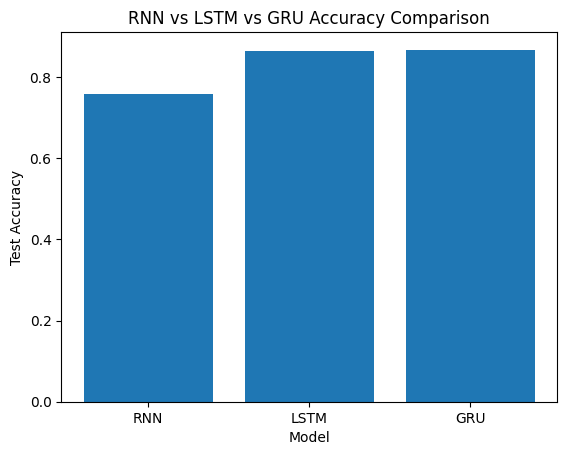

In [8]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()